<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Regularization Techniques**


In this lab, you will learn five regularization techniques that are commonly used in training neural networks. You will see how they are implemented using Keras and the result of applying each of them on a real world dataset.


## **Overfitting and Underfitting**

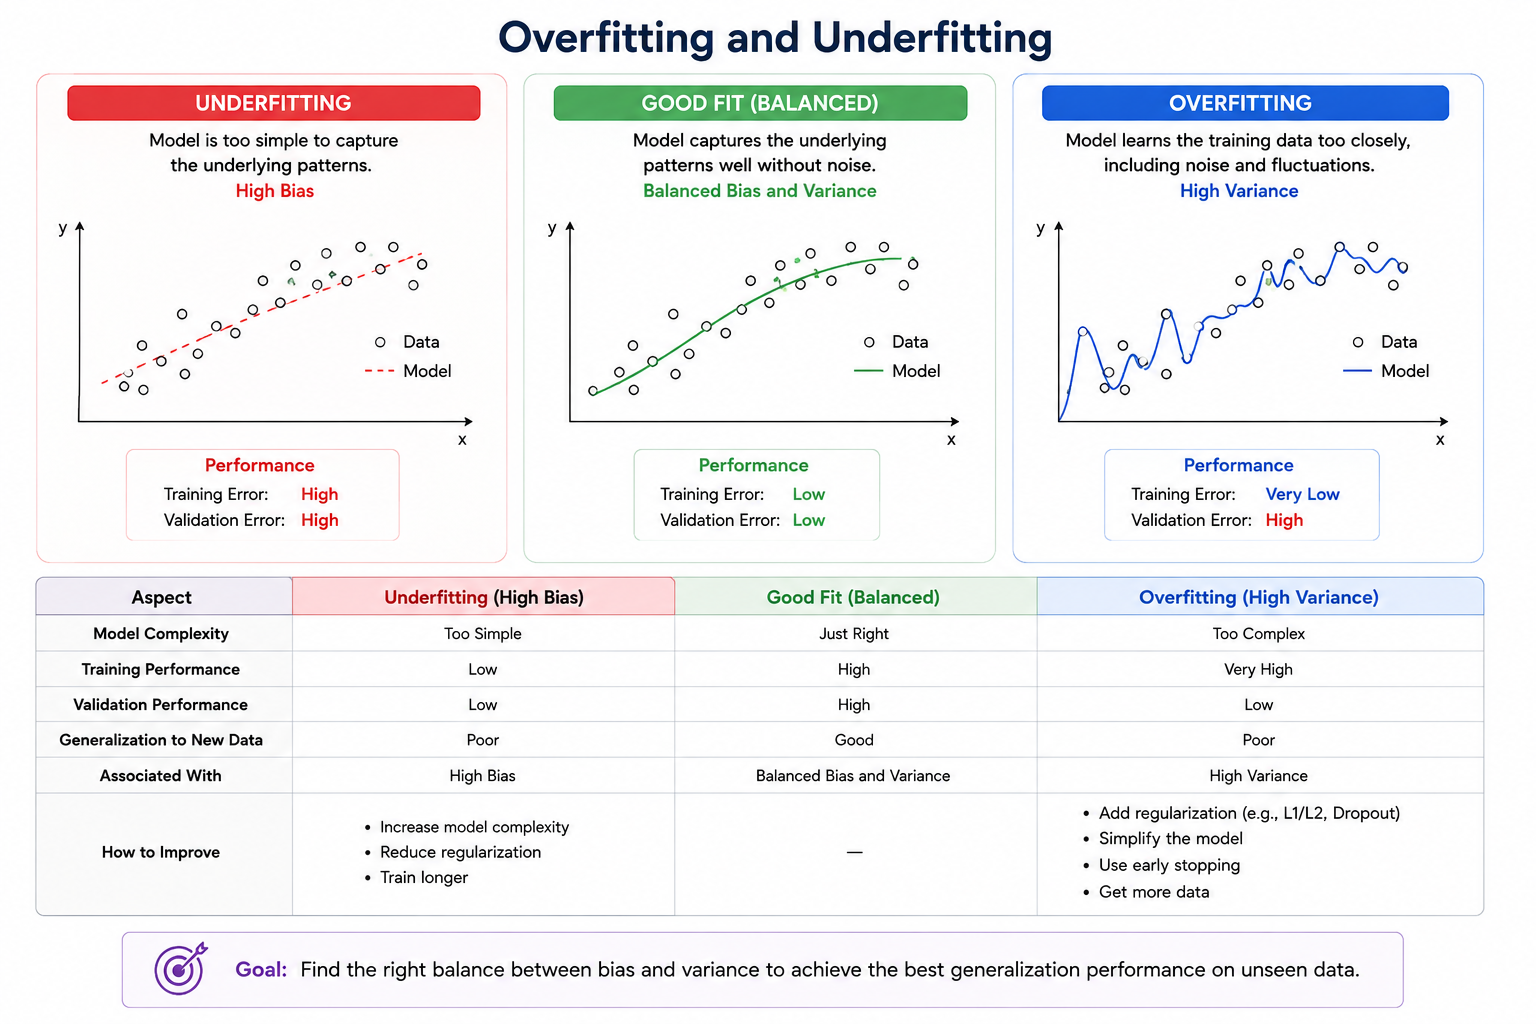
The goal of machine learning is to balance bias and variance so that the model generalizes well to new data.

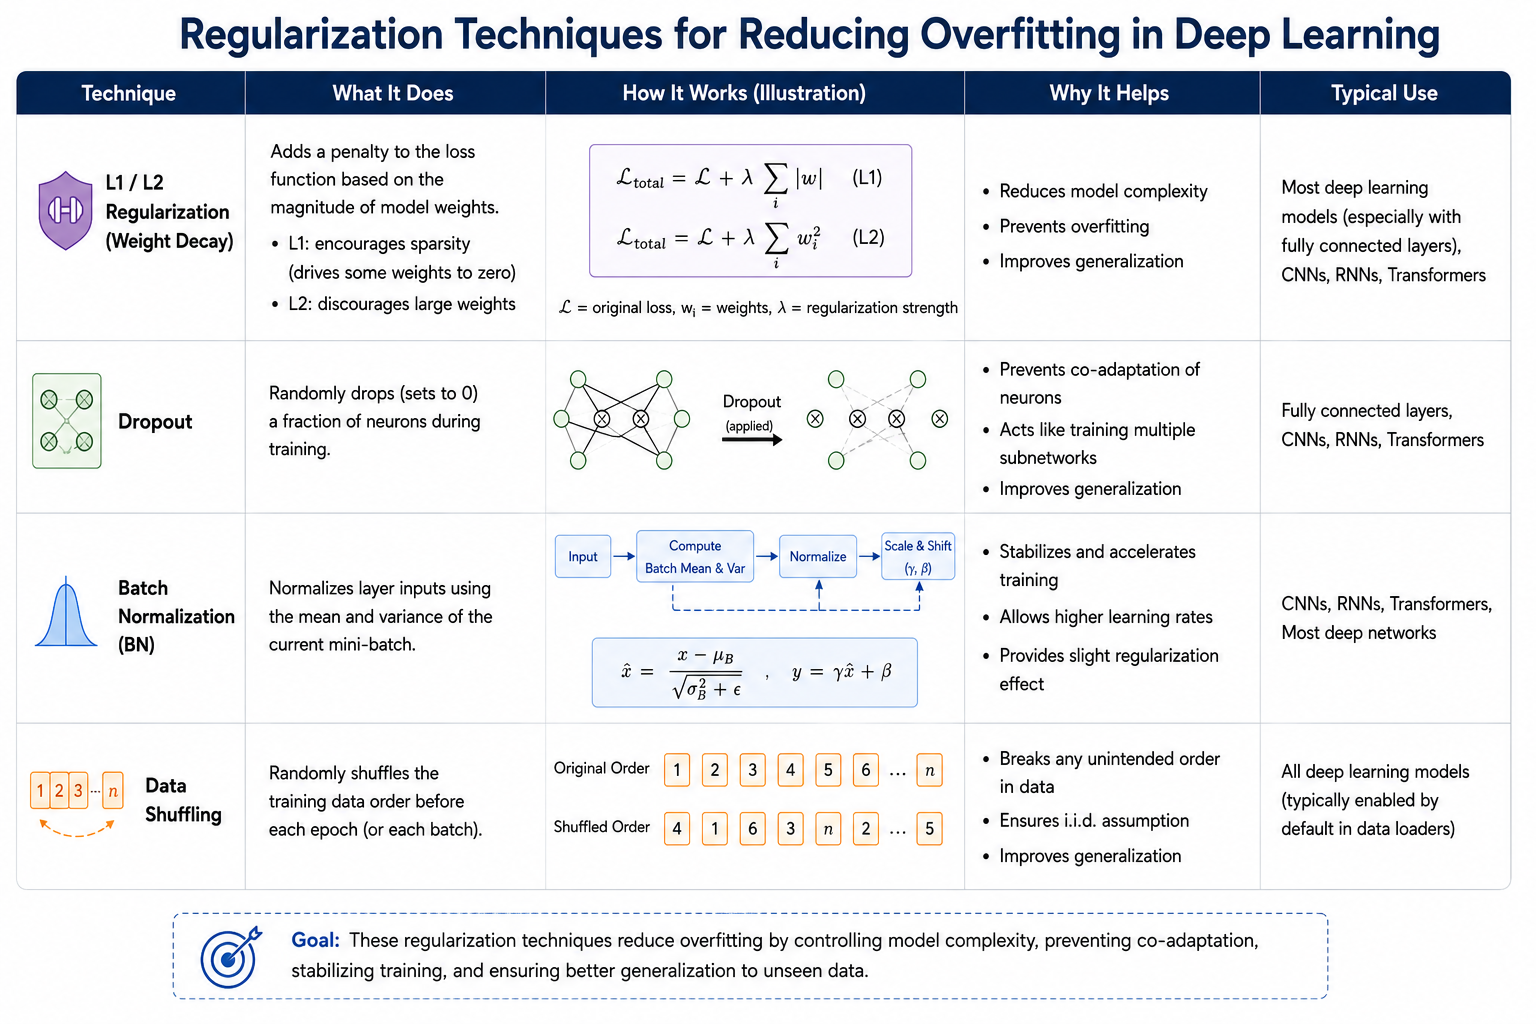

## **Table of Contents**

1. [Objectives](#toc-objectives)
2. [Setup](#toc-setup)
    1. [Installing Required Libraries](#toc-installing-required-libraries)
    2. [Importing Required Libraries](#toc-importing-required-libraries)
    3. [Defining Helper Functions](#toc-defining-helper-functions)
3. [Overfitting](#toc-overfitting)
4. [L2 Regularization](#toc-l2-regularization)
    1. [Using L2 Regularization in Keras](#toc-using-l2-regularization-in-keras)
5. [L1 Regularization](#toc-l1-regularization)
    1. [Using L1 Regularization in Keras](#toc-using-l1-regularization-in-keras)
6. [Dropout](#toc-dropout)
    1. [Using Dropout in Keras](#toc-using-dropout-in-keras)
7. [Batch Normalization](#toc-batch-normalization)
    1. [What is Batch Normalization?](#toc-what-is-batch-normalization)
    2. [How Does Batch Normalization Work?](#toc-how-does-batch-normalization-work)
    3. [Using Batch Normalization in Keras](#toc-using-batch-normalization-in-keras)
8. [Example 1: Apply regularization techniques on simulated data](#toc-example-1-apply-regularization-techniques-on-simulated-data)
    1. [L1 (Lasso)](#toc-l1-lasso))
    2. [L2 (Ridge)](#toc-l2-ridge))
    3. [Dropout](#toc-dropout-2)
    4. [Batch Norm](#toc-batch-norm)
9. [Data Shuffling](#toc-data-shuffling)
10. [Example 2: Spam Classification](#toc-example-2-spam-classification)
    1. [Model Configuration and Training](#toc-model-configuration-and-training)
    2. [Baseline: No Regularization](#toc-baseline-no-regularization)
    3. [L1 Regularization](#toc-l1-regularization-2)
    4. [L2 Regularization](#toc-l2-regularization-2)
    5. [Dropout](#toc-dropout-3)
    6. [Batch Normalization](#toc-batch-normalization-2)


## **Objectives** <a id="toc-objectives"></a>

After completing this lab you will be able to:

*   Understand how the regularization techniques (L1, L2, Dropout, BatchNorm) work for neural networks.
*   Describe the difference between L1 and L2 regularization.
*   Apply the four types of regularization when training neural networks.


***


## **Setup** <a id="toc-setup"></a>


For this lab, we will be using the following libraries:

*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`Pillow`](https://pillow.readthedocs.io/en/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for image processing functions.
*   [`OpenCV`](https://docs.opencv.org/4.x/index.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for other image processing functions.
*   [`tensorflow`](https://www.tensorflow.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and neural network related functions.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### **Installing Required Libraries** <a id="toc-installing-required-libraries"></a>

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (like Watson Studio or Anaconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the following code cell.


In [1]:
# All Libraries required for this lab are listed, as follows. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy numpy==1.22.3 matplotlib==3.5.1 tensorflow==2.9.0 opencv-python==4.5.5.62

# Note: If your environment doesn't support "!mamba install", use "!pip install --user"
#!pip install --upgrade tensorflow
# RESTART YOUR KERNEL AFTERWARD AS WELL

You will need the nltk library for this lab, make sure to install it.


In [ ]:
# %%capture
#!pip install nltk

### **Importing Required Libraries** <a id="toc-importing-required-libraries"></a>

*We recommend you import all required libraries in one place, as follows:*


In [3]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense

[nltk_data] Downloading package stopwords to /home/wusu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
I0000 00:00:1779723277.418085   14459 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779723277.419941   14459 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779723278.471238   14459 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779723278.472413   14459 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### **Defining Helper Functions** <a id="toc-defining-helper-functions"></a>


This function helps prepare the SMS Spam dataset.


In [4]:
def prepare_data():
    try:
        data = pd.read_csv("spam.csv", encoding="latin-1")
    except FileNotFoundError:
        print("Data file not found, make sure it's downloaded.")

    data.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1, inplace=True)
    data.rename(columns={"v1": "label", "v2": "text"}, inplace=True)
    data.label = data["label"].map({"ham": 0, "spam": 1})
    data["Count"] = data["text"].apply(lambda x: len(x))

    sw = stopwords.words("english")
    vectorizer = TfidfVectorizer(stop_words=sw, binary=True)

    X = vectorizer.fit_transform(data.text).toarray()
    y = data.label

    return X, y

This function plots the loss and accuracy curve from the training history of a neural network.


In [5]:
def plot_metrics(history):
    fig = plt.figure(figsize=(10, 5))
    for i, metric in enumerate(["accuracy", "loss"]):
        train_metrics = history.history[metric]
        val_metrics = history.history["val_" + metric]
        epochs = range(1, len(train_metrics) + 1)
        plt.subplot(1, 2, i + 1)
        plt.plot(epochs, train_metrics)
        plt.plot(epochs, val_metrics)
        plt.title("Training and validation " + metric)
        plt.xlabel("Epochs")
        plt.ylabel(metric)
        plt.legend(["train_" + metric, "val_" + metric])

## **Overfitting** <a id="toc-overfitting"></a>


In the following figure, we see a two-class classification problem. The red points represent one class, and the blue points represent the other class. The black line shows the true decision boundary. Most data points are located in the correct region, but a few points appear in the wrong region because of factors such as noise or outliers. In general, we do not expect many data points from these classes to appear in those regions.

The green curve represents a second model that tries to fit every training sample, including the unusual points in the incorrect regions. Although this model performs well on the training data, it does not generalize well to new data. This is because real-world data usually does not contain many samples in those unusual regions. As a result, the model performs poorly on unseen data. This problem is called **overfitting**.

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L3/images/Overfitting.png" width="40%"></center>

<p style="text-align:center">
    <a href="https://en.wikipedia.org/wiki/Overfitting">Source: Wikipedia</a>
</p>

To reduce overfitting, or high variance, we can apply regularization techniques when training a neural network. In this lab, we will introduce the following methods:

- L2 (Ridge) regularization
- L1 (Lasso) regularization
- Dropout
- Batch Normalization 
- Data shuffling


## **L2 Regularization** <a id="toc-l2-regularization"></a>


L2 regularization is one of the most common regularization techniques and is similar to the penalty term used in **Ridge regression**. It works by adding a penalty term to the loss function based on the squared values of the model weights.

The modified loss function is:

$$
Loss = Original\ Loss + \frac{1}{2}\lambda \sum w^2
$$

where:
- $w$ represents the model weights,
- $\lambda$ is the regularization strength, also called the **shrinkage parameter**.

The value of $\lambda$ controls how strongly large weights are penalized:
- Small $\lambda$ → weak regularization
- Large $\lambda$ → strong regularization

L2 regularization uses the Euclidean norm of the weight matrix, which is calculated by summing the squared weights. The factor $\frac12$ is included to simplify the gradient calculation, because the derivative of the penalty term becomes:

$$
\lambda w
$$

During training, L2 regularization encourages the model weights to become smaller. This helps reduce overfitting and improves generalization on unseen data.

As the shrinkage parameter $\lambda$ becomes very large, the weights move closer to zero, but they usually do **not become exactly zero**.

### **Using L2 Regularization in Keras** <a id="toc-using-l2-regularization-in-keras"></a>

In Keras, regularization penalties are applied on a per-layer basis, that is, you specify the name of the regularizer API as you add a layer to the network. The `tf.keras.regularizers` module has a built-in L2 class that you can call using the following:


In [6]:
tf.keras.regularizers.l2(0.01)

This object can be passed as an argument to a Dense layer:


In [7]:
dense_layer = Dense(
    32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01)
)

## **L1 Regularization** <a id="toc-l1-regularization"></a>

L1 regularization is another widely used regularization technique. It reduces overfitting by adding a penalty term based on the absolute values of the model weights.

The modified loss function is:

$$
Loss = Original\ Loss + \lambda \sum |w|
$$

where:
- $w$ represents the model weights,
- $\lambda$ is the regularization strength.

Unlike L2 regularization, L1 regularization can shrink some weights completely to zero when $\lambda$ becomes large. As a result, unimportant features are automatically removed from the model. This makes L1 regularization useful for **feature selection**.

<p style='color: blue'>The following figure illustrates the difference between L1 and L2 regularization:</p>


<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L3/images/L12_1.png" width="65%"></center>

<p style="text-align:center; color:gray">Source: An Introduction to Statistical Learning</p>


In the figure above:
- The red ellipses represent contours of the loss function.
- The green regions represent the feasible constraint regions for L1 and L2 regularization.

For L1 regularization (left figure), the feasible region has sharp corners. The loss contours can intersect at these corners, which often occurs on an axis where one or more weights become exactly zero.

For L2 regularization (right figure), the feasible region is circular because it is based on the L2 norm. The contours usually intersect the circle away from the axes, so the weights become small but rarely reach exactly zero.

We can also combine L1 and L2 regularization to create **Elastic Net regularization**:

$$
Loss = Original\ Loss + \frac{1}{2}\lambda_1 \sum w^2 + \lambda_2 \sum |w|
$$

where:
- $\lambda_1$ controls the L2 penalty,
- $\lambda_2$ controls the L1 penalty.

Both parameters can be tuned during training.

### **Using L1 Regularization in Keras** <a id="toc-using-l1-regularization-in-keras"></a>

Similar to how we used L2, `tf.keras.regularizers` module also has a built-in L1 class:


In [8]:
dense_layer = Dense(
    32, activation="relu", kernel_regularizer=tf.keras.regularizers.l1(0.01)
)

E0000 00:00:1779723278.971749   14459 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


If you don't need to specify a value for the regularization strength, you can also pass a string value to the `kernel_regularizer` argument:


In [9]:
dense_layer = Dense(32, activation="relu", kernel_regularizer="l1")

## **Dropout** <a id="toc-dropout"></a>

Dropout is a regularization technique used to reduce overfitting in neural networks. During training, each neuron is randomly kept active with probability $p$, or temporarily set to zero with probability $1-p$.

For example:

```python
Dropout(0.5)
```

means that each neuron has:
- a 50% probability of remaining active,
- and a 50% probability of being dropped during each training step.

<center>
<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L3/images/DO_1.png" width="60%">
</center>

<p style="text-align:center; color:gray">
Picture from the <a href="http://www.cs.toronto.edu/~rsalakhu/papers/srivastava14a.pdf">Dropout paper</a>
</p>

During each training iteration, Dropout randomly removes different neurons from the network. As a result, the model effectively trains many slightly different smaller neural networks instead of relying on a single fixed network.

This helps prevent neurons from becoming too dependent on one another, a problem called **co-adaptation**. The network is forced to learn more robust and general patterns, which improves performance on unseen data.

Mathematically, each neuron is controlled by a random mask variable:

$$
z_i =
\begin{cases}
0 & \text{with probability } p \\
1 & \text{with probability } 1-p
\end{cases}
$$

where:
- $p$ is the dropout probability,
- $z_i$ determines whether the neuron is removed or kept.

Dropout also adds controlled noise to the training process, making the model less sensitive to small variations in the training data and helping reduce overfitting.

Note that **Dropout is only used during training**. During prediction (inference), all neurons remain active.

### **Using Dropout in Keras** <a id="toc-using-dropout-in-keras"></a>

In Keras, Dropout can be applied using the Dropout class from **keras.layers**. A dropout rate can be specified when creating the dropout layer, which is the percentage of neurons that will be turned off during one update.


In [10]:
from tensorflow.keras.layers import Dropout

dropout_layer = Dropout(rate=0.2)

## **Batch Normalization** <a id="toc-batch-normalization"></a>

Training deep neural networks can be difficult because the distribution of inputs to each layer changes during training as the weights are updated through backpropagation. This problem is called **internal covariate shift** in the [original Batch Normalization paper](https://arxiv.org/abs/1502.03167) .

Because the input distributions keep changing, the model may train slowly and require:
- smaller learning rates,
- careful weight initialization,
- and longer training times.

Batch Normalization helps solve this problem by normalizing the inputs of each layer during training.


### **What is Batch Normalization?** <a id="toc-what-is-batch-normalization"></a>

Batch Normalization is a technique that normalizes the activations of a layer for each mini-batch during training. This stabilizes the learning process and allows deep neural networks to train faster and more reliably.

A **mini-batch** is a small group of training samples processed together during one training step.

**Normalization** means transforming data so that:
- the mean becomes 0,
- and the standard deviation becomes 1.

In a neural network, Batch Normalization adds a normalization layer between Dense layers. This layer keeps the input values of each layer more stable by controlling their mean and variance.

Because the input distributions do not change too much during training, the layers can learn more efficiently during backpropagation. This makes the training process faster and more stable.
```python
Dense → BatchNormalization → Activation
```

By keeping the input distributions more stable, the layers can learn more efficiently during backpropagation.


<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L3/images/BN_6.png" width="70%"></center>

Image credits to [Ilango Rajagopal](https://medium.com/@ilango100/batch-normalization-speed-up-neural-network-training-245e39a62f85)


### **How Does Batch Normalization Work?** <a id="toc-how-does-batch-normalization-work"></a>

Suppose a mini-batch $B$ contains $m$ training samples.

For each feature dimension $k$, Batch Normalization first calculates the mean and variance of the mini-batch:

$$
\mu_B^{k} = \frac{1}{m} \sum_{i=1}^m x_i^{k},
\quad
{\sigma_B^{k}}^2 = \frac{1}{m} \sum_{i=1}^m (x_i^{k}-\mu_B^{k})^2
$$

where:
- $\mu_B^{k}$ is the mean of feature $k$,
- ${\sigma_B^{k}}^2$ is the variance of feature $k$,
- $m$ is the mini-batch size,
- $x_i^{k}$ is the value of feature $k$ for sample $i$.

The input values are then normalized using the calculated mean and variance:

$$
\hat{x}_{i}^{k} =
\frac{x_i^{k}-\mu_B^{k}}
{\sqrt{{\sigma_B^{k}}^2+\epsilon}}
$$

where:
- $\hat{x}_{i}^{k}$ is the normalized value,
- $\epsilon$ is a very small constant added for numerical stability.

After normalization:
- the values have approximately mean 0,
- and standard deviation 1.

To preserve the flexibility of the network, Batch Normalization then applies a learnable scaling and shifting step:

$$
y_i^{k} =
\gamma^{k}\hat{x}_{i}^{k}+\beta^{k}
$$

where:
- $\gamma^{k}$ is a learnable scaling parameter,
- $\beta^{k}$ is a learnable shifting parameter.

These parameters are learned automatically during training.

<p style='color: blue'>What are the benefits of Batch Normalization?</p>

1. Faster Training: 
Batch Normalization keeps the input distributions of each layer more stable during training. This reduces the internal covariate shift problem and allows deep neural networks to train faster, often with larger learning rates.

2. More Stable Optimization: 
By normalizing the activations, Batch Normalization reduces large fluctuations in gradients and loss values during training. This makes the optimization process smoother, more stable, and easier for the model to learn.

3. Better Generalization: 
Each mini-batch is normalized using its own mean and standard deviation, which introduces a small amount of randomness during training. This acts as a mild regularizer and can help reduce overfitting, improving performance on unseen data.


### **Using Batch Normalization in Keras** <a id="toc-using-batch-normalization-in-keras"></a>

In Keras, you can add a Batch Norm layer between the Dense layers by calling `BatchNormalization()` from **keras.layers**. Here is a code example:


In [11]:
from tensorflow.keras.layers import Dense, BatchNormalization

batchnorm_layer = BatchNormalization()

## **Example 1: Apply regularization techniques on simulated data** <a id="toc-example-1-apply-regularization-techniques-on-simulated-data"></a>

In this example, we will use the **generate_data** function to simulate a degree-3 polynomial dataset with some random noise. We will intentionally overfit the data by creating polynomial features of the data, and then we will observe whether the four regularization techniques can mitigate overfitting in this case.


Let's first visualize the polynomial data:


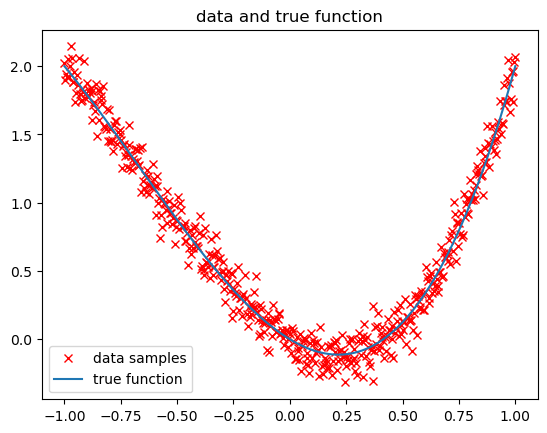

In [12]:
def generate_data(seed=43, std=0.1, samples=500):
    np.random.seed(seed)
    X = np.linspace(-1, 1, samples)
    f = X**3 + 2 * X**2 - X
    y = f + np.random.randn(samples) * std

    return X, y


X, y = generate_data()
f = X**3 + 2 * X**2 - X
plt.plot(X, y, "rx", label="data samples")
plt.plot(X, f, label="true function")
plt.title("data and true function")
plt.legend()
plt.show()

let's also add some outliers to y:


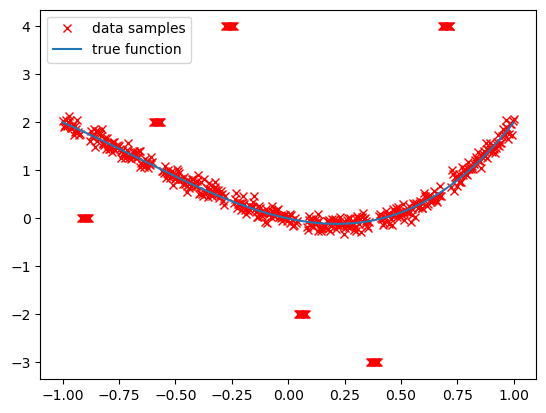

In [13]:
y[20:30] = 0
y[100:110] = 2
y[180:190] = 4
y[260:270] = -2
y[340:350] = -3
y[420:430] = 4

plt.plot(X, y, "rx", label="data samples")
plt.plot(X, f, label="true function")
plt.legend()
plt.show()

Let's use an overly complex neural network to fit our simulated data.


In [14]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(Dense(1000, activation="relu", input_shape=(1,)))
model.add(Dense(120, activation="relu"))
model.add(Dense(120, activation="relu"))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=1e-3), loss="mean_squared_error")
model.fit(X, y, epochs=20, batch_size=100)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6616  
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3157
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0420
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9758
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9391
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8941
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8700
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8242
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7914 
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7678
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7553
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7384
Epoch 13/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7313
Epoch 14/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7180
Epoch 15/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7090
Epoch 16/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/st

When we plot out the original data and the predictions, we can see that because the model's weights are not regularized, it tends to over fit  on new data: 


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


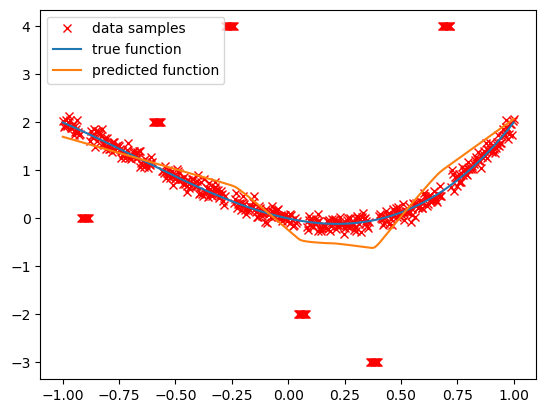

In [15]:
y_pred = model.predict(X)
plt.plot(X, y, "rx", label="data samples")
plt.plot(X, f, label="true function")
plt.plot(X, y_pred, label="predicted function")
plt.legend()
plt.show()

We can also calculate the mean square error:


In [16]:
no_reg = np.mean((y - y_pred) ** 2)
print(f"Mean squared error is {no_reg}\n")

Mean squared error is 1.9338763107883201



Now let's apply the four regularization techniques: **L1, L2, Drop out, and Batch Normalization** and see which works best for our data!


### **L1 (Lasso)** <a id="toc-l1-lasso"></a>


In [17]:
model_l1 = Sequential()

model_l1.add(
    Dense(
        1000,
        activation="relu",
        input_shape=(1,),
        kernel_regularizer=keras.regularizers.l1(0.01),
    )
)
model_l1.add(
    Dense(
        120,
        activation="relu",
        kernel_regularizer=keras.regularizers.l1(0.001),
    )
)
model_l1.add(Dense(120, activation="relu"))
model_l1.add(Dense(1))
model_l1.compile(optimizer=Adam(learning_rate=1e-3), loss="mean_squared_error")
model_l1.fit(X, y, epochs=20, batch_size=100)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1747  
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.3342 
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.6774
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.2256
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7623
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.3546
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.9869 
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6419
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3402
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0751
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8477
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6602
Epoch 13/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4995
Epoch 14/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3814
Epoch 15/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3036 
Epoch 16/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

We can plot the model, we see the model tracks the data: 


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


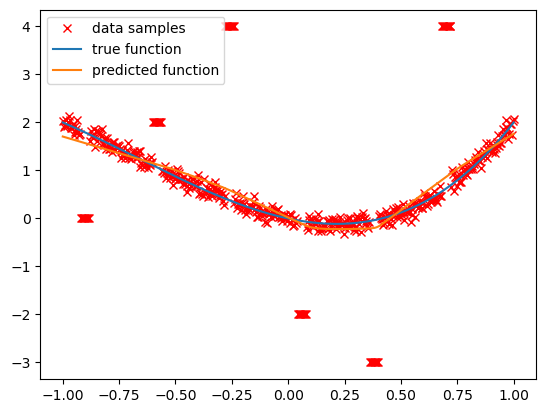

In [18]:
y_pred = model_l1.predict(X)
plt.plot(X, y, "rx", label="data samples")
plt.plot(X, f, label="true function")
plt.plot(X, y_pred, label="predicted function")
plt.legend()
plt.show()

We can also calculate the mean square error; we see L1 regulation decreases the error:


In [19]:
l1 = np.mean((y - y_pred) ** 2)
print(f"Mean squared error is {l1}\n")

Mean squared error is 1.7003783710412832



### **L2 (Ridge)** <a id="toc-l2-ridge"></a>


In [20]:
model_l2 = Sequential()

model_l2.add(
    Dense(
        1000,
        activation="relu",
        input_shape=(1,),
        kernel_regularizer=keras.regularizers.l2(0.0001),
    )
)
model_l2.add(
    Dense(
        120,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(0.0001),
    )
)
model_l2.add(
    Dense(
        120,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(0.0001),
    )
)
model_l2.add(Dense(1))
model_l2.compile(optimizer=Adam(learning_rate=1e-3), loss="mean_squared_error")
model_l2.fit(X, y, validation_split=0.2, epochs=20, batch_size=40)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1119 - val_loss: 3.4180
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7735 - val_loss: 4.7654
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7301 - val_loss: 4.7875
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7173 - val_loss: 4.1519
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7037 - val_loss: 4.3191
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6924 - val_loss: 4.2754
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6927 - val_loss: 3.7478
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6797 - val_loss: 4.0006
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6791 - val_loss: 3.6034
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6740 - val_loss: 3.7188
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6755 - val_loss: 2.9727
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6743 - val_lo

We can plot the model, we can also calculate the mean square error; we see L2 regulation can also improve the result by a little bit:


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


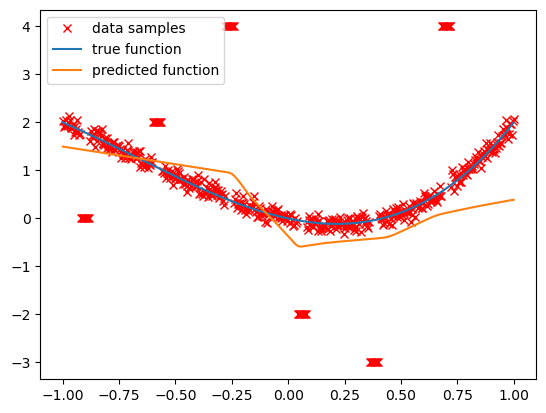

In [21]:
y_pred = model_l2.predict(X)
plt.plot(X, y, "rx", label="data samples")
plt.plot(X, f, label="true function")
plt.plot(X, y_pred, label="predicted function")
plt.legend()

In [22]:
l2 = np.mean((y - y_pred) ** 2)
print(f"Mean squared error is {l2}\n")

Mean squared error is 1.8761851836014534



### **Dropout** <a id="toc-dropout-2"></a>


In [23]:
model_dp = Sequential()

model_dp.add(Dense(1000, activation="relu", input_shape=(1,)))
model_dp.add(Dropout(0.1))
model_dp.add(Dense(120, activation="relu"))
model_dp.add(Dropout(0.1))
model_dp.add(Dense(120, activation="relu"))
model_dp.add(Dropout(0.1))
model_dp.add(Dense(1))
model_dp.compile(optimizer=Adam(learning_rate=1e-3), loss="mean_squared_error")
model_dp.fit(X, y, validation_split=0.2, epochs=20, batch_size=40)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.1315 - val_loss: 4.0156
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7251 - val_loss: 5.3021
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7066 - val_loss: 4.1274
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6931 - val_loss: 4.1389
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6820 - val_loss: 4.3864
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6736 - val_loss: 4.0386
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6731 - val_loss: 3.6003
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6841 - val_loss: 3.2709
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6579 - val_loss: 3.2124
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6609 - val_loss: 2.8246
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6577 - val_loss: 2.5949
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6484 - val_lo

Let's plot the prediction and calculate the mean square error;


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


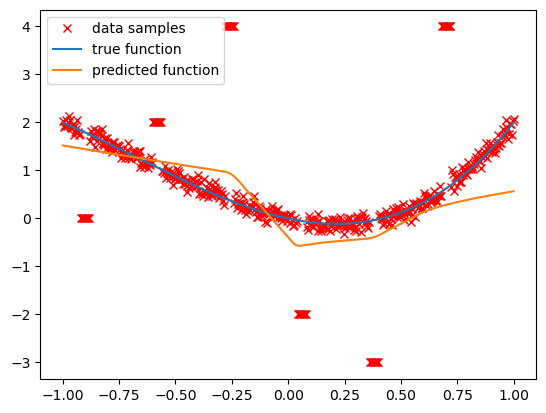

In [24]:
y_pred = model_dp.predict(X)
plt.plot(X, y, "rx", label="data samples")
plt.plot(X, f, label="true function")
plt.plot(X, y_pred, label="predicted function")
plt.legend()

In [25]:
dp = np.mean((y - y_pred) ** 2)
print(f"Mean squared error is {dp}\n")

Mean squared error is 1.8201409102159531



### **Batch Norm** <a id="toc-batch-norm"></a>


In [26]:
model_bn = Sequential()

model_bn.add(Dense(1000, activation="relu", input_shape=(1,)))
model_bn.add(BatchNormalization())
model_bn.add(Dense(120, activation="relu"))

model_bn.add(Dense(120, activation="relu"))
model_bn.add(Dense(1))
model_bn.compile(optimizer=Adam(learning_rate=1e-3), loss="mean_squared_error")
model_bn.fit(X, y, validation_split=0.2, epochs=20, batch_size=40)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9064 - val_loss: 2.9457
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7481 - val_loss: 3.0038
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7520 - val_loss: 3.0541
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7405 - val_loss: 2.9879
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7196 - val_loss: 2.9725
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6887 - val_loss: 2.9972
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6943 - val_loss: 2.8801
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7090 - val_loss: 2.8902
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6417 - val_loss: 2.9529
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6557 - val_loss: 2.9456
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6957 - val_loss: 2.7826
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6778 - val_lo

We can observe that due to a stronger regularization of Batch Normalization, the model does not seem to fit the data very well. However, the mean square error actually shows a big improvement.


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


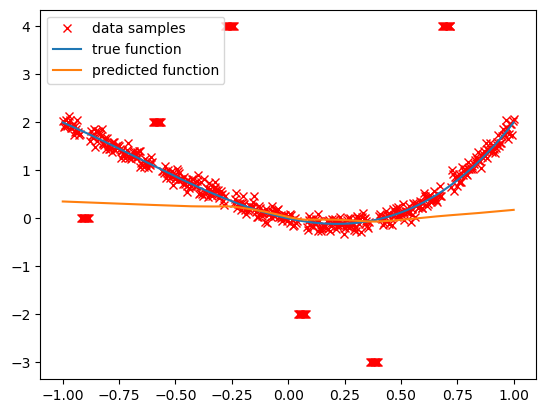

In [27]:
y_pred = model_bn.predict(X)
plt.plot(X, y, "rx", label="data samples")
plt.plot(X, f, label="true function")
plt.plot(X, y_pred, label="predicted function")
plt.legend()

In [28]:
bn = np.mean((y - y_pred) ** 2)
print(f"Mean squared error is {bn}\n")

Mean squared error is 1.6253873233533616



The regularization methods improved the MSE values slightly, but the predicted function became visually farther from the true function. This indicates that the regularization may have been too strong, causing the neural network to underfit the data.


## **Data Shuffling** <a id="toc-data-shuffling"></a>

To apply data shuffling to avoid overfitting, we can simpy call `shuffle=True` when fitting the model.


In [29]:
model_sh = Sequential()

model_sh.add(Dense(1000, activation="relu", input_shape=(1,)))
model_sh.add(Dense(120, activation="relu"))
model_sh.add(Dense(120, activation="relu"))
model_sh.add(Dense(1))

model_sh.compile(optimizer=Adam(learning_rate=1e-3), loss="mean_squared_error")
model_sh.fit(X, y, validation_split=0.2, epochs=20, batch_size=40, shuffle=True)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2047 - val_loss: 4.5490
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7467 - val_loss: 4.6870
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6953 - val_loss: 4.3395
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6924 - val_loss: 3.6218
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6758 - val_loss: 4.3292
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6637 - val_loss: 3.8823
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6585 - val_loss: 3.7756
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6693 - val_loss: 3.5939
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6479 - val_loss: 3.2263
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6457 - val_loss: 3.1271
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6460 - val_loss: 3.0462
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6498 - val_lo

We can also calculate the mean square error on the data. Data shuffling doesn't seem to be very effective for our data.


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


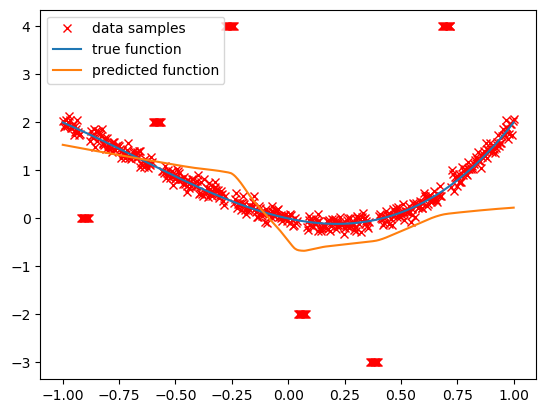

In [30]:
y_pred = model_sh.predict(X)

plt.plot(X, y, "rx", label="data samples")
plt.plot(X, f, label="true function")
plt.plot(X, y_pred, label="predicted function")
plt.legend()

In [31]:
sh = np.mean((y - y_pred) ** 2)
print(f"Mean squared error is {sh}\n")

Mean squared error is 1.93605129272976



Let's compare the mean squared errors of the networks trained using different regularization techniques:


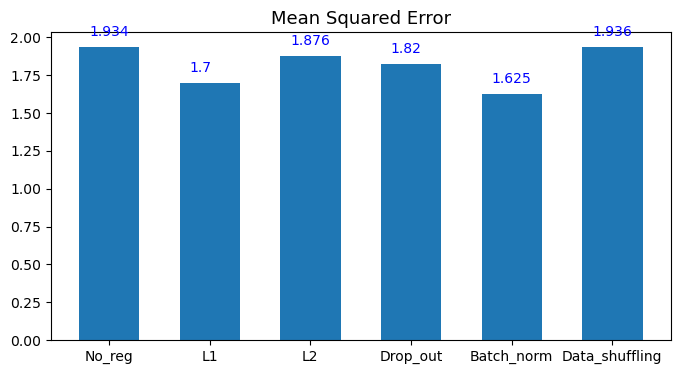

In [32]:
names = ["No_reg", "L1", "L2", "Drop_out", "Batch_norm", "Data_shuffling"]
error = [no_reg, l1, l2, dp, bn, sh]

plt.figure(figsize=(8, 4))
plt.bar(names, error, width=0.6)
plt.title("Mean Squared Error", fontsize=13)

for i, err in enumerate(error):
    plt.text(i - 0.2, err + 0.1, str(round(err, 3)), color="blue", va="center")

Given the comparison of the mean squared errors, we can conclude that Batch Normalization works best for the simulated dataset.

The regularization methods improved the MSE values slightly, but in several cases the predicted functions became visually farther from the true function. This indicates that the regularization may have been too strong, causing the neural network to underfit the data.

Regularization helps reduce overfitting by simplifying the model and producing smoother predictions. However, excessive regularization can make the model too simple to capture the true underlying pattern of the data.

This example demonstrates that lower MSE values do not always guarantee a visually better fit to the true function. It also highlights the importance of carefully tuning regularization strength to balance overfitting and underfitting.

In practice, there is no single regularization method that works best for every dataset. Different techniques and hyperparameter settings should be evaluated based on both quantitative metrics and qualitative model behavior.

Now, let's move on to a real world dataset.


## **Example 2: Spam Classification** <a id="toc-example-2-spam-classification"></a>

In this example, we will dive into a real world application, which is a spam classification problem. We will work with the [SMS Spam Collection Dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) from Kaggle and use neural networks for classifying a message as either Spam or Ham (not spam).

We first download and display the raw dataset:


In [33]:
import skillsnetwork

await skillsnetwork.download(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L3/data/spam.csv"
)

Saved as 'spam.csv'


In [34]:
data = pd.read_csv("spam.csv", encoding="latin-1")
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


By calling the helper function **prepare_data**, we obtain a matrix $\boldsymbol X$ which contains the pre-processed text data (mainly using the **TfidfVectorizer** from scikit-learn's **feature_extraction** module) and an object $\boldsymbol y$ which contains the labels of the messages. 

There are 5572 text messages that will be classified as either spam **(1)** or non-spam **(0)**, and they are 8536-dimensional data.


In [35]:
X, y = prepare_data()
X.shape, y.shape

((5572, 8536), (5572,))

### **Model Configuration and Training** <a id="toc-model-configuration-and-training"></a>


The **get_model** function provides the layer configuration ane the training of a neural network for different specifications of the regularization technique used. For example, by setting `reg='L1'`, the network's Dense layers will be regularized by L1, and then at the end of the training, the loss and accuracy curve of the train and validation set will be plotted.


In [36]:
input_dim = X.shape[1]


def get_model(reg=None, epochs=10):
    model = Sequential()
    model.add(Dense(512, activation="relu", input_shape=(input_dim,)))
    if reg == "L1":
        model.add(Dense(256, activation="relu", kernel_regularizer="l1"))
        model.add(Dense(64, activation="relu", kernel_regularizer="l1"))
    elif reg == "L2":
        model.add(Dense(256, activation="relu", kernel_regularizer="l2"))
        model.add(Dense(64, activation="relu", kernel_regularizer="l2"))
    elif reg == "Dropout":
        model.add(Dropout(0.2))
        model.add(Dense(256, activation="relu"))
        model.add(Dropout(0.2))
        model.add(Dense(64, activation="relu"))
        model.add(Dropout(0.2))
    elif reg == "BatchNorm":
        model.add(BatchNormalization())
        model.add(Dense(256, activation="relu"))
        model.add(BatchNormalization())
        model.add(Dense(64, activation="relu"))
        model.add(BatchNormalization())
    else:
        model.add(Dense(256, activation="relu"))
        model.add(Dense(64, activation="relu"))

    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
    )
    history = model.fit(
        X, y, batch_size=64, validation_split=0.2, epochs=epochs
    )
    plot_metrics(history)

### **Baseline: No Regularization** <a id="toc-baseline-no-regularization"></a>


Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8714 - loss: 0.2638 - val_accuracy: 0.9713 - val_loss: 0.1305
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9946 - loss: 0.0685 - val_accuracy: 0.9803 - val_loss: 0.0674
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9993 - loss: 0.0039 - val_accuracy: 0.9776 - val_loss: 0.0812
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 3.8207e-04 - val_accuracy: 0.9776 - val_loss: 0.0898
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 1.5680e-04 - val_accuracy: 0.9776 - val_loss: 0.0967
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 9.0574e-05 - val_accuracy: 0.9776 - val_loss: 0.1003
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 5.9623e-05 - val_accuracy: 0.9776 - val_loss: 0.1047
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 4.2501e-05 - val_accuracy

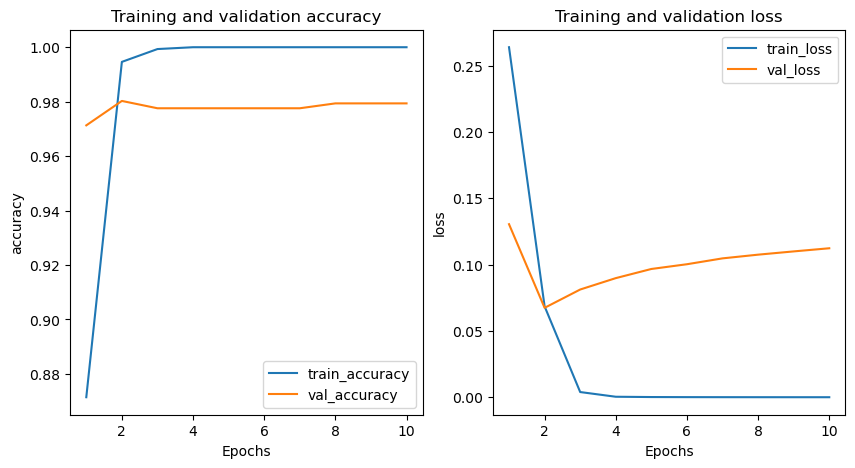

In [37]:
get_model()

The plots show clear signs of overfitting. As training progresses, the training accuracy quickly reaches nearly 100%, while the validation accuracy stops improving and remains lower than the training accuracy.

Similarly, the training loss continues decreasing toward zero, but the validation loss begins to increase after a few epochs. This means the model is learning the training data too closely, including noise and small fluctuations, rather than learning general patterns that transfer well to unseen data.

The increasing gap between the training and validation performance indicates that the model is overfitting to the training dataset.

### **L1 Regularization** <a id="toc-l1-regularization-2"></a>


Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8535 - loss: 32.4003 - val_accuracy: 0.8700 - val_loss: 6.5021
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8649 - loss: 2.1158 - val_accuracy: 0.8700 - val_loss: 0.6761
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8649 - loss: 0.6042 - val_accuracy: 0.8700 - val_loss: 0.5696
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8649 - loss: 0.5746 - val_accuracy: 0.8700 - val_loss: 0.5638
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8649 - loss: 0.5733 - val_accuracy: 0.8700 - val_loss: 0.5641
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8649 - loss: 0.5732 - val_accuracy: 0.8700 - val_loss: 0.5627
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8649 - loss: 0.5731 - val_accuracy: 0.8700 - val_loss: 0.5631
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8649 - loss: 0.5729 - val_accuracy: 0.8700 - val_loss

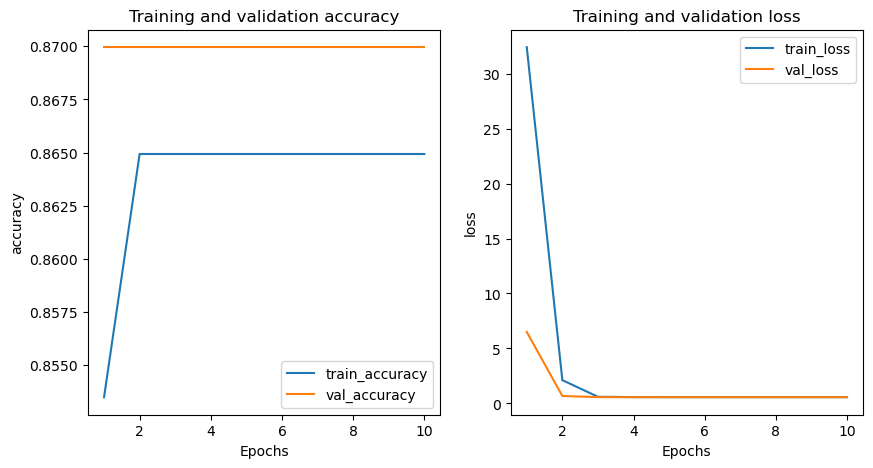

In [38]:
get_model(reg="L1")

The plots show that L1 regularization reduced the overfitting problem. The training and validation accuracies are now very close, and the validation accuracy is slightly higher than the training accuracy. In addition, the training and validation losses remain similar throughout training, indicating that the model is more stable and no longer memorizing the training data.

However, both the training and validation accuracies are much lower than those of the baseline model. While the baseline model achieved validation accuracies above 0.97, the L1-regularized model remains around 0.87. This indicates that the regularization strength is too strong and the model has become too simple to learn the underlying patterns in the data.

Therefore, although L1 regularization successfully reduced overfitting, it also caused the model to underfit the dataset.

### **L2 Regularization** <a id="toc-l2-regularization-2"></a>


Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8571 - loss: 2.0862 - val_accuracy: 0.9300 - val_loss: 0.5569
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9816 - loss: 0.2731 - val_accuracy: 0.9758 - val_loss: 0.1632
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9964 - loss: 0.0915 - val_accuracy: 0.9803 - val_loss: 0.1151
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9989 - loss: 0.0615 - val_accuracy: 0.9776 - val_loss: 0.1043
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9993 - loss: 0.0492 - val_accuracy: 0.9785 - val_loss: 0.0954
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9996 - loss: 0.0417 - val_accuracy: 0.9740 - val_loss: 0.1080
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9998 - loss: 0.0357 - val_accuracy: 0.9758 - val_loss: 0.0955
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9998 - loss: 0.0316 - val_accuracy: 0.9776 - val_loss:

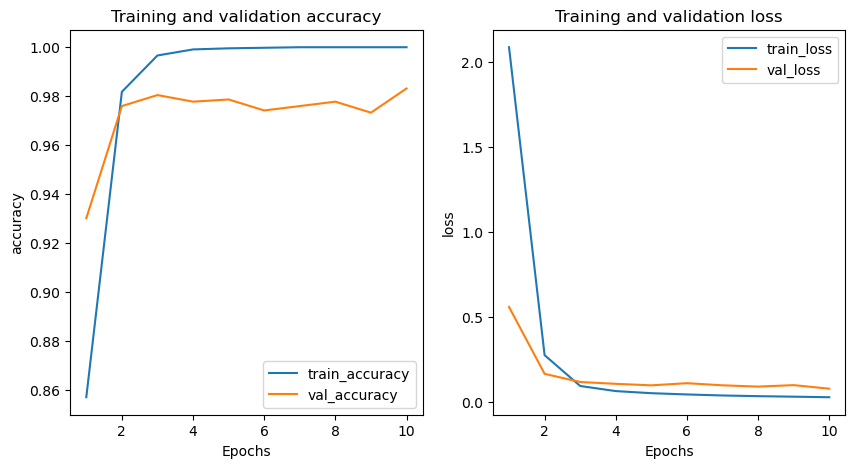

In [39]:
get_model(reg="L2")

The plots show that L2 regularization reduced the overfitting problem compared to the baseline model. The gap between the training and validation accuracies became smaller, indicating that the model generalized slightly better to unseen data.

Unlike the baseline model, the training accuracy did not remain exactly at 100%, showing that L2 regularization prevented the model from fitting the training data too aggressively. The training and validation losses also remained relatively close throughout training.

However, some fluctuations are still present in the validation accuracy and validation loss, suggesting that a certain amount of overfitting still exists. Overall, L2 regularization improved the balance between training and validation performance while maintaining high accuracy.

### **Dropout** <a id="toc-dropout-3"></a>


Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8647 - loss: 0.2850 - val_accuracy: 0.9632 - val_loss: 0.1370
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9890 - loss: 0.0621 - val_accuracy: 0.9794 - val_loss: 0.0756
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9989 - loss: 0.0059 - val_accuracy: 0.9803 - val_loss: 0.0799
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9998 - loss: 0.0017 - val_accuracy: 0.9812 - val_loss: 0.0918
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 2.7510e-04 - val_accuracy: 0.9812 - val_loss: 0.1024
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 1.4199e-04 - val_accuracy: 0.9812 - val_loss: 0.1102
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 7.8602e-05 - val_accuracy: 0.9794 - val_loss: 0.1181
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 5.1169e-05 - val_accuracy: 0.

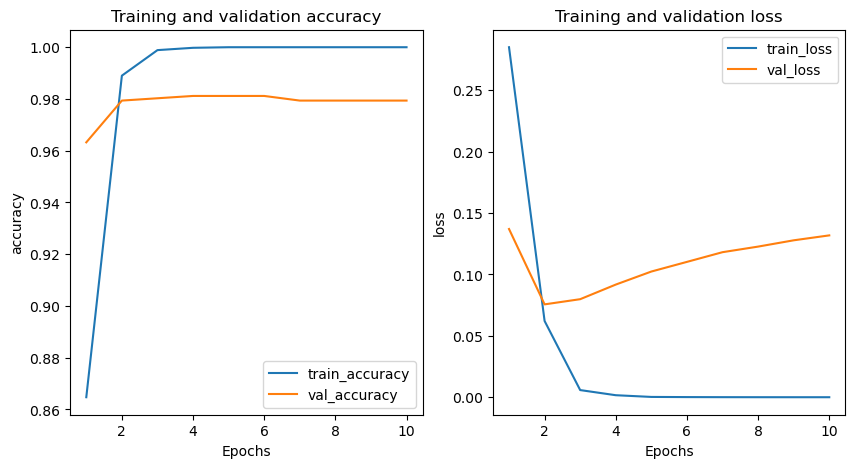

In [40]:
get_model(reg="Dropout")

The plots show that the model trained with Dropout behaves similarly to the baseline model. The training accuracy still reaches nearly 100%, while the validation accuracy remains around 98%. In addition, the validation loss gradually increases during training, which suggests that some overfitting is still present.

Compared to the baseline model, Dropout only slightly reduced the gap between the training and validation performance. This indicates that, with the current dropout setting, Dropout did not significantly improve generalization for this dataset.

Overall, Dropout provided only a modest regularization effect in this example. This also highlights that the effectiveness of regularization techniques depends on the dataset, model architecture, and hyperparameter settings.

### **Batch Normalization** <a id="toc-batch-normalization-2"></a>


Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8737 - loss: 0.2597 - val_accuracy: 0.9713 - val_loss: 0.1346
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9944 - loss: 0.0533 - val_accuracy: 0.9776 - val_loss: 0.0816
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 0.9776 - val_loss: 0.1189
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 2.6087e-04 - val_accuracy: 0.9776 - val_loss: 0.1087
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 9.4851e-05 - val_accuracy: 0.9776 - val_loss: 0.1133
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 5.9188e-05 - val_accuracy: 0.9776 - val_loss: 0.1175
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 4.0537e-05 - val_accuracy: 0.9776 - val_loss: 0.1208
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 2.9736e-05 - val_accuracy

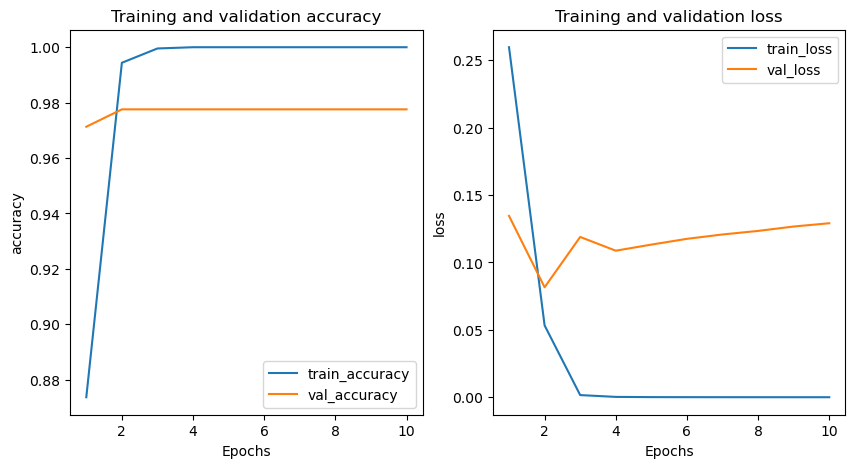

In [41]:
get_model(reg="BathNorm")

With Batch Norm, the final training accuracy is 1.0 and final validation accuracy is 0.9812, which is slightly higher than before (0.9794). We can conclude that Batch Normalization is a relatively better choice for regularizing neural network training.

The plots show that Batch Normalization slightly improved the model's generalization performance compared to the baseline model. The validation accuracy is marginally higher, and the gap between training and validation accuracy is slightly smaller.

However, the overall behavior remains similar to the baseline model. The training accuracy still quickly reaches nearly 100%, while the validation accuracy stabilizes around 98%. In addition, the validation loss gradually increases during later epochs, indicating that some overfitting is still present.

Therefore, Batch Normalization provided a modest regularization effect in this example, improving training stability and slightly reducing overfitting, but it did not completely eliminate the overfitting behavior.

## **Authors**


[Roxanne Li](https://www.linkedin.com/in/roxanne-li/) is a Data Scientist at IBM Skills Network.

Su Wu


## **Change Log**


| Date (YYYY-MM-DD) | Version | Changed By  | Change Description |
| ----------------- | ------- | ----------- | ------------------ |
| 2022-07-18      | 0.1     | Roxanne Li  | Created Lab|
| 2022-09-07      | 0.1     | Steve Hord  | QA pass edits|
| 2026-05-24     | 0.1     | Su Wu| Documentation and script edit    |


Copyright © 2022 IBM Corporation. All rights reserved.
